In [861]:
# %%writefile -a plot_utils.py
# %%writefile -a model_utils.py
# %%writefile create_pipelines.py
# %%writefile -a feature_engineering.py

import time
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_predict, cross_val_score
from sklearn.metrics import precision_score, recall_score, classification_report, f1_score
from sklearn.base import TransformerMixin, BaseEstimator
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, RocCurveDisplay
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

import warnings
warnings.filterwarnings("ignore")

In [862]:
train = pd.read_csv("../data/titanic.csv")
train.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [863]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [864]:
train.duplicated().sum()

0

In [865]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [866]:
train.Survived.value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [867]:
X = train.drop(columns=["Survived"], axis="columns")
y = train["Survived"]

In [868]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.05, random_state=42)

In [869]:
X_train.shape, X_val.shape

((846, 11), (45, 11))

In [870]:
X_train.columns

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [871]:
test_data = pd.DataFrame({
        'PassengerId': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
        'Age': [25., 42., 28., 35., 57., 22., 31., 45., None, 60., 33., 29.],
        'Fare': [10.0, 120.0, None, 45.0, 87.0, 15.0, 60.0, 200.0, 8.0, 150.0, 75.0, 25.0],
        'Sex': ['female', 'male', 'None', 'male', 'male', 'female', 'male', 'female', 'male', 'female', 'male', 'female'],
        'Name': ['Sarah', 'Ali', 'Mina', 'Dr', 'Hadi', 'Lily', 'John', None, 'Mike', 'Anna', 'Tom', 'Lisa'],
        'Ticket': [1563, 15678, 8674, 4531, 8565, 9234, 6745, 3456, None, 4567, 8934, 5678],
        'Pclass': [2, 1, 3, 1, 2, 3, 2, None, 3, 1, 2, 3],
        'SibSp': [0, 1, 0, 2, 3, 1, 0, 1, 2, 0, None, 0],
        'Parch': [0, 1, None, 0, 4, 1, 0, 2, 1, 0, 1, 0],
        'Cabin': ['A1', None, 'B2', 'C3', 'F21', 'D4', None, 'E5', 'G6', 'H7', None, 'I8'], 
        'Embarked': ['S', 'Q', 'S', 'C', 'C', 'Q', 'S', 'C', 'Q', None, 'C', 'Q']
    })

In [872]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  12 non-null     int64  
 1   Age          11 non-null     float64
 2   Fare         11 non-null     float64
 3   Sex          12 non-null     object 
 4   Name         11 non-null     object 
 5   Ticket       11 non-null     float64
 6   Pclass       11 non-null     float64
 7   SibSp        11 non-null     float64
 8   Parch        11 non-null     float64
 9   Cabin        9 non-null      object 
 10  Embarked     11 non-null     object 
dtypes: float64(6), int64(1), object(4)
memory usage: 1.2+ KB


### Age Fare Log

In [873]:
# %%writefile -a feature_engineering.py
class AgeFareLog(BaseEstimator, TransformerMixin):
    def __init__(self, age = "Age", age_log= "AgeLog", pclass = "Pclass", 
                 sex = "Sex", fare = "Fare", fare_log = "FareLog"):
        
        self.age = age
        self.age_log = age_log
        self.pclass = pclass
        self.sex = sex
        self.fare = fare
        self.fare_log = fare_log

    def fit(self, X: pd.DataFrame, y=None):
        return self
    
    def transform(self, X: pd.DataFrame):
        new_data = X.copy()
        
        new_data[self.age] = new_data[self.age].fillna(new_data.groupby([self.sex, self.pclass])[self.age].transform("median"))
        new_data[self.age] = new_data[self.age].fillna(new_data[self.age].median())
        new_data[self.fare] = new_data[self.fare].fillna(new_data[self.fare].mean())

        new_data[self.age_log] = np.log1p(new_data[self.age])
        new_data[self.fare_log] = np.log1p(new_data[self.fare])
        # new_data.drop(columns=[self.age, self.fare], inplace=True)

        return new_data

In [874]:
age_fare_log = AgeFareLog()
test_data = age_fare_log.fit_transform(test_data) 
print("After AgeFareLog:", test_data.columns.tolist())

After AgeFareLog: ['PassengerId', 'Age', 'Fare', 'Sex', 'Name', 'Ticket', 'Pclass', 'SibSp', 'Parch', 'Cabin', 'Embarked', 'AgeLog', 'FareLog']


In [875]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  12 non-null     int64  
 1   Age          12 non-null     float64
 2   Fare         12 non-null     float64
 3   Sex          12 non-null     object 
 4   Name         11 non-null     object 
 5   Ticket       11 non-null     float64
 6   Pclass       11 non-null     float64
 7   SibSp        11 non-null     float64
 8   Parch        11 non-null     float64
 9   Cabin        9 non-null      object 
 10  Embarked     11 non-null     object 
 11  AgeLog       12 non-null     float64
 12  FareLog      12 non-null     float64
dtypes: float64(8), int64(1), object(4)
memory usage: 1.3+ KB


### Has Family

In [ ]:
# %%writefile -a feature_engineering.py
class HasFamily(BaseEstimator, TransformerMixin):
    def __init__(self, sibsp="SibSp", parch="Parch", has_family="HasFamily"):
        self.sibsp = sibsp
        self.parch = parch
        self.has_family = has_family

    def fit(self, X:pd.DataFrame, y=None):
        return self

    def transform(self, X:pd.DataFrame):
        new_data = X.copy()
        family_size =  X[self.sibsp] + X[self.parch]
        new_data[self.has_family] = family_size.fillna(0)
        new_data[self.has_family] = family_size.apply(lambda x: 1 if x>=1 else 0).fillna(0)

        return new_data

In [877]:
has_family = HasFamily()
test_data = has_family.fit_transform(test_data)
print("After HasFamily:", test_data.columns.tolist())

After HasFamily: ['PassengerId', 'Age', 'Fare', 'Sex', 'Name', 'Ticket', 'Pclass', 'SibSp', 'Parch', 'Cabin', 'Embarked', 'AgeLog', 'FareLog', 'HasFamily']


In [878]:
test_data

,PassengerId,Age,Fare,Sex,Name,Ticket,Pclass,SibSp,Parch,Cabin,Embarked,AgeLog,FareLog,HasFamily
0,1,25.0,10.000000,female,Sarah,1563.0,2.0,0.0,0.0,A1,S,3.258097,2.397895,0
1,2,42.0,120.000000,male,Ali,15678.0,1.0,1.0,1.0,None,Q,3.761200,4.795791,1
2,3,28.0,72.272727,None,Mina,8674.0,3.0,0.0,NaN,B2,S,3.367296,4.294188,0
3,4,35.0,45.000000,male,Dr,4531.0,1.0,2.0,0.0,C3,C,3.583519,3.828641,1
4,5,57.0,87.000000,male,Hadi,8565.0,2.0,3.0,4.0,F21,C,4.060443,4.477337,1
5,6,22.0,15.000000,female,Lily,9234.0,3.0,1.0,1.0,D4,Q,3.135494,2.772589,1
6,7,31.0,60.000000,male,John,6745.0,2.0,0.0,0.0,None,S,3.465736,4.110874,0
7,8,45.0,200.000000,female,None,3456.0,NaN,1.0,2.0,E5,C,3.828641,5.303305,1
8,9,33.0,8.000000,male,Mike,NaN,3.0,2.0,1.0,G6,Q,3.526361,2.197225,1
9,10,60.0,150.000000,female,Anna,4567.0,1.0,0.0,0.0,H7,None,4.110874,5.017280,0


In [879]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  12 non-null     int64  
 1   Age          12 non-null     float64
 2   Fare         12 non-null     float64
 3   Sex          12 non-null     object 
 4   Name         11 non-null     object 
 5   Ticket       11 non-null     float64
 6   Pclass       11 non-null     float64
 7   SibSp        11 non-null     float64
 8   Parch        11 non-null     float64
 9   Cabin        9 non-null      object 
 10  Embarked     11 non-null     object 
 11  AgeLog       12 non-null     float64
 12  FareLog      12 non-null     float64
 13  HasFamily    12 non-null     int64  
dtypes: float64(8), int64(2), object(4)
memory usage: 1.4+ KB


### Has Cabin

In [880]:
# %%writefile -a feature_engineering.py
class HasCabin(BaseEstimator, TransformerMixin):
    def __init__(self, cabin="Cabin", has_cabin="HasCabin"):
        self.cabin = cabin
        self.has_cabin = has_cabin

    def fit(self, X:pd.DataFrame, y=None):
        return self
    
    def transform(self, X:pd.DataFrame):
        new_data = X.copy()
        new_data[self.cabin] = new_data[self.cabin].astype("str")
        new_data[self.cabin] = new_data[self.cabin].apply(lambda x: x.replace(x, x[0]) if x not in "nan" else "N")
        new_data[self.cabin] = new_data[self.cabin].fillna("N")
        new_data[self.has_cabin] = new_data[self.cabin].apply(lambda x: 0 if x == "N" else 1).fillna(0)
        

        return new_data 

In [881]:
has_cabin = HasCabin() 
test_data = has_cabin.fit_transform(test_data)
print("After HasCabin:", test_data.columns.tolist())

After HasCabin: ['PassengerId', 'Age', 'Fare', 'Sex', 'Name', 'Ticket', 'Pclass', 'SibSp', 'Parch', 'Cabin', 'Embarked', 'AgeLog', 'FareLog', 'HasFamily', 'HasCabin']


In [882]:
test_data.head(5)

,PassengerId,Age,Fare,Sex,Name,Ticket,Pclass,SibSp,Parch,Cabin,Embarked,AgeLog,FareLog,HasFamily,HasCabin
0,1,25.0,10.000000,female,Sarah,1563.0,2.0,0.0,0.0,A,S,3.258097,2.397895,0,1
1,2,42.0,120.000000,male,Ali,15678.0,1.0,1.0,1.0,N,Q,3.761200,4.795791,1,0
2,3,28.0,72.272727,None,Mina,8674.0,3.0,0.0,NaN,B,S,3.367296,4.294188,0,1
3,4,35.0,45.000000,male,Dr,4531.0,1.0,2.0,0.0,C,C,3.583519,3.828641,1,1
4,5,57.0,87.000000,male,Hadi,8565.0,2.0,3.0,4.0,F,C,4.060443,4.477337,1,1


In [883]:
test_data.HasCabin.value_counts()

HasCabin
1    9
0    3
Name: count, dtype: int64

In [884]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  12 non-null     int64  
 1   Age          12 non-null     float64
 2   Fare         12 non-null     float64
 3   Sex          12 non-null     object 
 4   Name         11 non-null     object 
 5   Ticket       11 non-null     float64
 6   Pclass       11 non-null     float64
 7   SibSp        11 non-null     float64
 8   Parch        11 non-null     float64
 9   Cabin        12 non-null     object 
 10  Embarked     11 non-null     object 
 11  AgeLog       12 non-null     float64
 12  FareLog      12 non-null     float64
 13  HasFamily    12 non-null     int64  
 14  HasCabin     12 non-null     int64  
dtypes: float64(8), int64(3), object(4)
memory usage: 1.5+ KB


In [885]:
# %%writefile -a feature_engineering.py
class PclassImputer(BaseEstimator, TransformerMixin):
    def __init__(self, pclass="Pclass", sex="Sex", has_cabin="HasCabin"):
        self.pclass = pclass
        self.sex = sex
        self.has_cabin = has_cabin       

    def fit(self, X:pd.DataFrame, y=None):
        return self
    
    def transform(self, X:pd.DataFrame):
        new_data = X.copy()
        new_data[self.sex] = new_data[self.sex].fillna(new_data[self.sex].mode().iloc[0])
        new_data[self.has_cabin] = new_data[self.has_cabin].fillna(0)
        new_data[self.pclass] = new_data[self.pclass].fillna(
            new_data.groupby([self.sex, self.has_cabin])[self.pclass].transform(
                lambda x: x.mode().iloc[0] if any(x.mode()) else np.nan
            ))
        new_data[self.pclass] = new_data[self.pclass].fillna(new_data[self.pclass].mode().iloc[0])

        return new_data

In [886]:
pclass_imputer = PclassImputer()
test_data = pclass_imputer.fit_transform(test_data)
print("After PclassImputer:", test_data.columns.tolist())

After PclassImputer: ['PassengerId', 'Age', 'Fare', 'Sex', 'Name', 'Ticket', 'Pclass', 'SibSp', 'Parch', 'Cabin', 'Embarked', 'AgeLog', 'FareLog', 'HasFamily', 'HasCabin']


In [887]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  12 non-null     int64  
 1   Age          12 non-null     float64
 2   Fare         12 non-null     float64
 3   Sex          12 non-null     object 
 4   Name         11 non-null     object 
 5   Ticket       11 non-null     float64
 6   Pclass       12 non-null     float64
 7   SibSp        11 non-null     float64
 8   Parch        11 non-null     float64
 9   Cabin        12 non-null     object 
 10  Embarked     11 non-null     object 
 11  AgeLog       12 non-null     float64
 12  FareLog      12 non-null     float64
 13  HasFamily    12 non-null     int64  
 14  HasCabin     12 non-null     int64  
dtypes: float64(8), int64(3), object(4)
memory usage: 1.5+ KB


In [888]:
test_data.head()

,PassengerId,Age,Fare,Sex,Name,Ticket,Pclass,SibSp,Parch,Cabin,Embarked,AgeLog,FareLog,HasFamily,HasCabin
0,1,25.0,10.000000,female,Sarah,1563.0,2.0,0.0,0.0,A,S,3.258097,2.397895,0,1
1,2,42.0,120.000000,male,Ali,15678.0,1.0,1.0,1.0,N,Q,3.761200,4.795791,1,0
2,3,28.0,72.272727,None,Mina,8674.0,3.0,0.0,NaN,B,S,3.367296,4.294188,0,1
3,4,35.0,45.000000,male,Dr,4531.0,1.0,2.0,0.0,C,C,3.583519,3.828641,1,1
4,5,57.0,87.000000,male,Hadi,8565.0,2.0,3.0,4.0,F,C,4.060443,4.477337,1,1


In [889]:
pclass_cabin_pipeline = Pipeline([
    ("has_cabin", HasCabin()),
    ("pclass_imputer", PclassImputer())
])

In [890]:
sex_embark_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

In [ ]:
sex_embark = ColumnTransformer(transformers=[
    ("sex_embark", sex_embark_pipeline, ["Sex", "Embarked"]),
    ("pass_through", "passthrough", ["Pclass", "HasFamily", "HasCabin", "AgeLog", "FareLog"]),
])

In [ ]:
preprocessing = Pipeline([
    ("has_family", HasFamily()),
    ("pclass_hascabin", pclass_cabin_pipeline),
    ("age_fare_log", AgeFareLog()),
    ("sex_embark_encode", sex_embark),
])

In [893]:
preprocessing.named_steps

{'has_family': HasFamily(),
 'pclass_hascabin': Pipeline(steps=[('has_cabin', HasCabin()), ('pclass_imputer', PclassImputer())]),
 'age_fare_log': AgeFareLog(),
 'sex_embark_encode': ColumnTransformer(transformers=[('sex_embark',
                                  Pipeline(steps=[('imputer',
                                                   SimpleImputer(strategy='most_frequent')),
                                                  ('onehot',
                                                   OneHotEncoder(drop='first',
                                                                 handle_unknown='ignore'))]),
                                  ['Sex', 'Embarked']),
                                 ('pass_through', 'passthrough',
                                  ['Pclass', 'HasFamily', 'HasCabin', 'AgeLog',
                                   'FareLog'])])}

In [894]:
test_data_1 = pd.DataFrame({
        'PassengerId': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
        'Age': [25., 42., 28., 35., 57., 22., 31., 45., None, 60., 33., 29.],
        'Fare': [10.0, 120.0, None, 45.0, 87.0, 15.0, 60.0, 200.0, 8.0, 150.0, 75.0, 25.0],
        'Sex': ['female', 'male', 'None', 'male', 'male', 'female', 'male', 'female', 'male', 'female', 'male', 'female'],
        'Name': ['Sarah', 'Ali', 'Mina', 'Dr', 'Hadi', 'Lily', 'John', None, 'Mike', 'Anna', 'Tom', 'Lisa'],
        'Ticket': [1563, 15678, 8674, 4531, 8565, 9234, 6745, 3456, None, 4567, 8934, 5678],
        'Pclass': [2, 1, 3, 1, 2, 3, 2, None, 3, 1, 2, 3],
        'SibSp': [0, 1, 0, 2, 3, 1, 0, 1, 2, 0, None, 0],
        'Parch': [0, 1, None, 0, 4, 1, 0, 2, 1, 0, 1, 0],
        'Cabin': ['A1', None, 'B2', 'C3', 'F21', 'D4', None, 'E5', 'G6', 'H7', None, 'I8'], 
        'Embarked': ['S', 'Q', 'S', 'C', 'C', 'Q', 'S', 'C', 'Q', None, 'C', 'Q']
    })

In [895]:
preprocessing.fit(test_data_1)

,steps,"[('has_family', ...), ('pclass_hascabin', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,sibsp,'SibSp'
,parch,'Parch'
,has_family,'HasFamily'
,steps,"[('has_cabin', ...), ('pclass_imputer', ...)]"
,transform_input,None
,memory,None
,verbose,False


In [896]:
test_data_1

,PassengerId,Age,Fare,Sex,Name,Ticket,Pclass,SibSp,Parch,Cabin,Embarked
0,1,25.0,10.0,female,Sarah,1563.0,2.0,0.0,0.0,A1,S
1,2,42.0,120.0,male,Ali,15678.0,1.0,1.0,1.0,None,Q
2,3,28.0,NaN,None,Mina,8674.0,3.0,0.0,NaN,B2,S
3,4,35.0,45.0,male,Dr,4531.0,1.0,2.0,0.0,C3,C
4,5,57.0,87.0,male,Hadi,8565.0,2.0,3.0,4.0,F21,C
5,6,22.0,15.0,female,Lily,9234.0,3.0,1.0,1.0,D4,Q
6,7,31.0,60.0,male,John,6745.0,2.0,0.0,0.0,None,S
7,8,45.0,200.0,female,None,3456.0,NaN,1.0,2.0,E5,C
8,9,NaN,8.0,male,Mike,NaN,3.0,2.0,1.0,G6,Q
9,10,60.0,150.0,female,Anna,4567.0,1.0,0.0,0.0,H7,None


In [897]:
preprocessed = preprocessing.transform(test_data_1)

In [898]:
preprocessed.shape

(12, 10)

In [899]:
preprocessed

array([[1.        , 0.        , 0.        , 1.        , 0.        ,
        2.        , 0.        , 1.        , 3.25809654, 2.39789527],
       [0.        , 1.        , 1.        , 0.        , 0.        ,
        1.        , 1.        , 0.        , 3.76120012, 4.79579055],
       [0.        , 0.        , 0.        , 1.        , 0.        ,
        3.        , 0.        , 1.        , 3.36729583, 4.29418847],
       [0.        , 1.        , 0.        , 0.        , 0.        ,
        1.        , 1.        , 1.        , 3.58351894, 3.8286414 ],
       [0.        , 1.        , 0.        , 0.        , 0.        ,
        2.        , 1.        , 1.        , 4.06044301, 4.47733681],
       [1.        , 0.        , 1.        , 0.        , 0.        ,
        3.        , 1.        , 1.        , 3.13549422, 2.77258872],
       [0.        , 1.        , 0.        , 1.        , 0.        ,
        2.        , 0.        , 0.        , 3.4657359 , 4.11087386],
       [1.        , 0.        , 0.       

In [900]:
print("After PclassImputer:", test_data_1.columns.tolist())

After PclassImputer: ['PassengerId', 'Age', 'Fare', 'Sex', 'Name', 'Ticket', 'Pclass', 'SibSp', 'Parch', 'Cabin', 'Embarked']


In [901]:
test_data_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  12 non-null     int64  
 1   Age          11 non-null     float64
 2   Fare         11 non-null     float64
 3   Sex          12 non-null     object 
 4   Name         11 non-null     object 
 5   Ticket       11 non-null     float64
 6   Pclass       11 non-null     float64
 7   SibSp        11 non-null     float64
 8   Parch        11 non-null     float64
 9   Cabin        9 non-null      object 
 10  Embarked     11 non-null     object 
dtypes: float64(6), int64(1), object(4)
memory usage: 1.2+ KB


In [902]:
print(X_train.dtypes)

PassengerId      int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [903]:
logistic_clf = Pipeline([
    ("preprocess", preprocessing),
    ("clf", LogisticRegression(random_state=42))
])

In [904]:
print(X_train.columns.tolist())

['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [905]:
pd.DataFrame(preprocessing.fit_transform(X_train)).head()

,0,1,2,3,4,5,6,7
0,1.0,0.0,1.0,3.0,1.0,0.0,2.833213,3.566005
1,1.0,0.0,1.0,3.0,0.0,0.0,2.995732,2.214661
2,1.0,0.0,1.0,3.0,0.0,0.0,3.178054,2.324836
3,1.0,0.0,1.0,3.0,0.0,0.0,3.218876,2.085672
4,1.0,0.0,0.0,1.0,1.0,1.0,4.077537,4.738608


In [906]:
logistic_clf.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('has_family', ...), ('pclass_hascabin', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,sibsp,'SibSp'
,parch,'Parch'
,has_family,'HasFamily'


In [907]:
# %%writefile -a model_utils.py

def scores(classifier, X, y, cv):
    acc = cross_val_score(classifier, X, y, cv=cv, scoring="accuracy").mean()
    roc = cross_val_score(classifier, X, y, cv=cv, scoring="roc_auc").mean()
    y_pred = cross_val_predict(classifier, X, y, cv=cv)
    precision = precision_score(y, y_pred) * 100
    recall = recall_score(y, y_pred) * 100
    f1 = f1_score(y, y_pred) * 100

    return acc, roc, precision, recall, f1

### Logistic Regression

In [908]:
X_train.columns

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [909]:
acc, roc, precision, recall, f1 = scores(logistic_clf, X_train, y_train, cv=5)

In [910]:
print('K-fold Results on Logistic Regression Classifier:')
print(f'average accuracy is: {acc*100:.2f}%')
print(f'average roc is: {roc*100:.2f}%')
print("-"*50)
print('Precision, Recall and f1 scores: ')
print(f'Precision: {precision:.2f}%')
print(f'Recall: {recall:.2f}%')
print(f'F1 Score: {f1:.2f}%')

K-fold Results on Logistic Regression Classifier:
average accuracy is: 80.02%
average roc is: 85.07%
--------------------------------------------------
Precision, Recall and f1 scores: 
Precision: 74.92%
Recall: 71.91%
F1 Score: 73.39%


In [911]:
y_pred = cross_val_predict(logistic_clf, X_train, y_train, cv=5)
conf_val = confusion_matrix(y_train, y_pred)
conf_val

array([[444,  78],
       [ 91, 233]], dtype=int64)

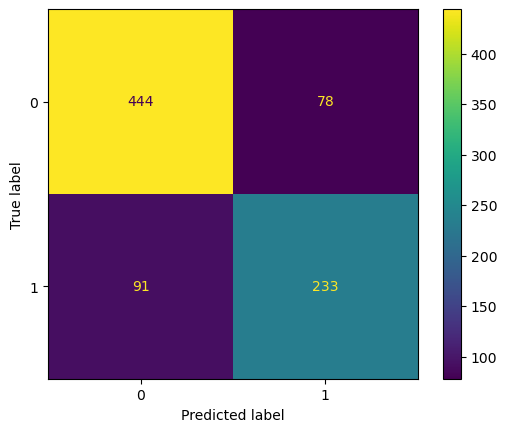

In [912]:
disp = ConfusionMatrixDisplay(conf_val, display_labels=logistic_clf.classes_)
disp.plot()
plt.show()

True Negative: 447

True Positive: 231

False Positive: 75

False Negative: 93

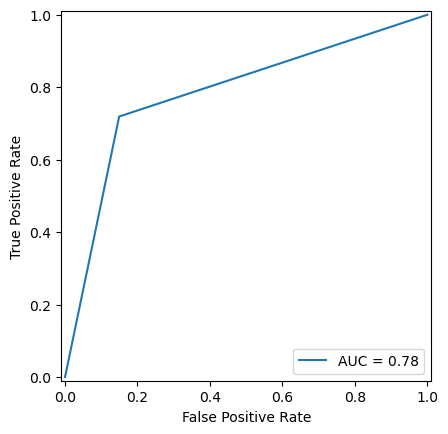

In [913]:
fpr, tpr, threshlds = roc_curve(y_train, y_pred)
roc_auc = auc(fpr, tpr)
display_roc = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc)
display_roc.plot()
plt.show()

In [914]:
print(classification_report(y_train, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.85      0.84       522
           1       0.75      0.72      0.73       324

    accuracy                           0.80       846
   macro avg       0.79      0.78      0.79       846
weighted avg       0.80      0.80      0.80       846



### Stochastic Gradient Decsent (SGD) 

In [915]:
sgd_clf = Pipeline([
    ("preprocess", preprocessing),
    ("classifier", SGDClassifier(random_state=42))
])

In [916]:
sgd_clf.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('has_family', ...), ('pclass_hascabin', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,sibsp,'SibSp'
,parch,'Parch'
,has_family,'HasFamily'


In [917]:
y_train_predict = cross_val_predict(sgd_clf, X_train, y_train, cv=5)

In [918]:
confusion = confusion_matrix(y_train, y_train_predict)
print(confusion)

[[375 147]
 [125 199]]


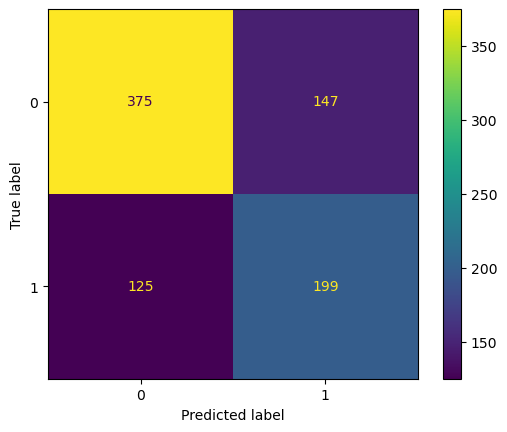

In [919]:
disp = ConfusionMatrixDisplay(confusion_matrix=confusion, 
                              display_labels=sgd_clf.classes_)
disp.plot()
plt.show()

True Negative: 472

True Positive: 178

False Positive: 50

False Negative: 146

In [920]:
acc, roc, precision, recall, f1 = scores(sgd_clf, X_train, y_train, cv=5)

In [921]:
print('K-fold Results on SGD Classifier:')
print(f'average accuracy is: {acc*100:.2f}%')
print(f'average roc is: {roc*100:.2f}%')
print("-"*50)
print('Precision, Recall and f1 scores: ')
print(f'Precision: {precision:.2f}%')
print(f'Recall: {recall:.2f}%')
print(f'F1 Score: {f1:.2f}%')

K-fold Results on SGD Classifier:
average accuracy is: 67.83%
average roc is: 83.79%
--------------------------------------------------
Precision, Recall and f1 scores: 
Precision: 57.51%
Recall: 61.42%
F1 Score: 59.40%


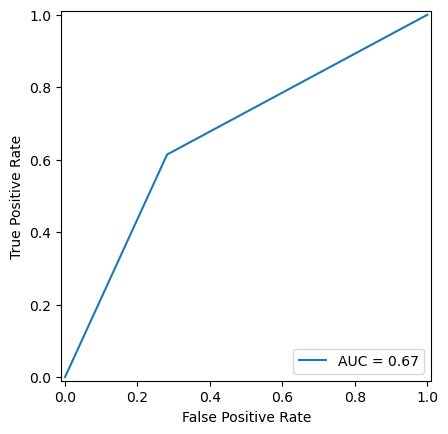

In [922]:
fpr, tpr, threshlds = roc_curve(y_train, y_train_predict)
roc_auc = auc(fpr, tpr)
display_roc = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc)
display_roc.plot()
plt.show()

In [923]:
print(classification_report(y_true=y_train, y_pred=y_train_predict))

              precision    recall  f1-score   support

           0       0.75      0.72      0.73       522
           1       0.58      0.61      0.59       324

    accuracy                           0.68       846
   macro avg       0.66      0.67      0.66       846
weighted avg       0.68      0.68      0.68       846



In [924]:
y_val_pred = sgd_clf.predict(X_val)

In [925]:
print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

           0       0.79      0.96      0.87        27
           1       0.92      0.61      0.73        18

    accuracy                           0.82        45
   macro avg       0.85      0.79      0.80        45
weighted avg       0.84      0.82      0.81        45



In [926]:
acc, roc, precision, recall, f1 = scores(sgd_clf, X_val, y_val, cv=5)

In [927]:
print('K-fold Results on SGD Classifier:')
print(f'average accuracy is: {acc*100:.2f}%')
print(f'average roc is: {roc*100:.2f}%')
print("-"*50)
print('Precision, Recall and f1 scores: ')
print(f'Precision: {precision:.2f}%')
print(f'Recall: {recall:.2f}%')
print(f'F1 Score: {f1:.2f}%')

K-fold Results on SGD Classifier:
average accuracy is: 68.89%
average roc is: 70.22%
--------------------------------------------------
Precision, Recall and f1 scores: 
Precision: 62.50%
Recall: 55.56%
F1 Score: 58.82%


In [928]:
conf_val = confusion_matrix(y_val, y_val_pred)
print(conf_val)

[[26  1]
 [ 7 11]]


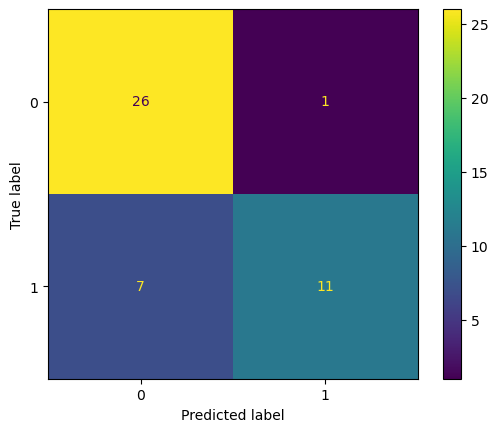

In [929]:
conf_val_disp = ConfusionMatrixDisplay(conf_val, display_labels=sgd_clf.classes_)
conf_val_disp.plot()
plt.show()

### Supprot Vector Classifier (SVC)

In [930]:
svc_clf = Pipeline([
    ("preprocessing", preprocessing),
    ("classifier", SVC(random_state=42))
])

In [931]:
acc, roc, precision, recall, f1 = scores(svc_clf, X_train, y_train, cv=5)

In [932]:
print('K-fold Results on SVC:')
print(f'average accuracy is: {acc*100:.2f}%')
print(f'average roc is: {roc*100:.2f}%')
print("-"*50)
print('Precision, Recall and f1 scores: ')
print(f'Precision: {precision:.2f}%')
print(f'Recall: {recall:.2f}%')
print(f'F1 Score: {f1:.2f}%')

K-fold Results on SVC:
average accuracy is: 80.14%
average roc is: 84.86%
--------------------------------------------------
Precision, Recall and f1 scores: 
Precision: 75.16%
Recall: 71.91%
F1 Score: 73.50%


In [933]:
svc_clf.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('has_family', ...), ('pclass_hascabin', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,sibsp,'SibSp'
,parch,'Parch'
,has_family,'HasFamily'


### Decision Tree

In [934]:
decision_tree_clf = Pipeline([
    ("preprocessing", preprocessing),
    ("classifier", DecisionTreeClassifier(random_state=42))
    ])

### Random Forest 

In [935]:
random_forest_clf = Pipeline([
    ("preprocessing", preprocessing),
    ("classifier", RandomForestClassifier(random_state=42))
])

## using Mlflow

In [936]:
# import mlflow
# import mlflow.sklearn
# from mlflow.models import infer_signature

In [937]:
# mlflow.set_experiment("Titanic Survival Prediction")
# mlflow.set_tracking_uri("file:./mlruns")
# #mlflow.set_tracking_uri("http://localhost:5000")

# def eval_and_log(model, model_name, X_train, y_train, X_test, y_test):
#     with mlflow.start_run(run_name=model_name):
#         model.fit(X_train, y_train)
#         # train_pred = model.predict(X_train)
#         # test_pred = model.predict(X_test)
#         # metrics
#         # train_recall = recall_score(y_train, train_pred)
#         # train_precision = precision_score(y_train, train_pred)
#         # train_f1 = f1_score(y_train, train_pred)

#         # test_recall = recall_score(y_test, test_pred)
#         # test_precision = precision_score(y_test, test_pred)
#         # test_f1 = f1_score(y_test, test_pred)
#         eval_data = X_test.copy()
#         eval_data["label"] = y_test

#         signature = infer_signature(X_test, model.predict(X_test))
#         model_info = mlflow.sklearn.log_model(model, name="model", signature=signature)

#         # Comprehensive evaluation
#         result = mlflow.models.evaluate(
#             model_info.model_uri,
#             eval_data,
#             targets="label",
#             model_type="classifier",
#             evaluators=["default"],
#         )

#         metrics = {"precision": result.metrics["precision_score"],
#                    "recall": result.metrics['recall_score'],
#                    "f1_score": result.metrics['f1_score'],
#                    "roc_auc": result.metrics['roc_auc']}
#         mlflow.log_metrics(metrics=metrics)
#         # precision = result.metrics["precision_score"]
#         # recall = result.metrics['recall_score']
#         # f1_score = result.metrics['f1_score']
#         # roc_auc = result.metrics['roc_auc']

#         # print(f"Precision: {result.metrics['precision_score']:.3f}")
#         # print(f"Recall: {result.metrics['recall_score']:.3f}")
#         # print(f"F1 Score: {result.metrics['f1_score']:.3f}")
#         # print(f"ROC AUC: {result.metrics['roc_auc']:.3f}")

In [938]:
# eval_and_log(logistic_clf, "Logistic Regression", X_train, y_train, X_val, y_val)
# #eval_and_log(sgd_clf, "SGD Classifier", X_train, y_train, X_val, y_val)
# eval_and_log(decision_tree_clf, "Decision Tree Classifier", X_train, y_train, X_val, y_val)
# eval_and_log(random_forest_clf, "Random Forest Classifier", X_train, y_train, X_val, y_val)
# #eval_and_log(svc_clf, "SVM Classifier", X_train, y_train, X_val, y_val)
# #eval_and_log(naive_bayes_clf, "Naive Bayes Classifier", X_train, y_train, X_val, y_val)


in anaconda poweshell: mlflow ui

In [939]:
test = pd.read_csv("../data/test.csv", index_col="PassengerId")
test.tail(4)

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,
1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S
1309,3,"Peter, Master. Michael J",male,NaN,1,1,2668,22.3583,NaN,C


In [940]:
test.iloc[10]

Pclass                     3
Name        Ilieff, Mr. Ylio
Sex                     male
Age                      NaN
SibSp                      0
Parch                      0
Ticket                349220
Fare                  7.8958
Cabin                    NaN
Embarked                   S
Name: 902, dtype: object

In [941]:
predict = sgd_clf.predict(test)
predict[10]

0

In [942]:
predict[12]

1

In [943]:
test.iloc[12]

Pclass                                                  1
Name        Snyder, Mrs. John Pillsbury (Nelle Stevenson)
Sex                                                female
Age                                                  23.0
SibSp                                                   1
Parch                                                   0
Ticket                                              21228
Fare                                              82.2667
Cabin                                                 B45
Embarked                                                S
Name: 904, dtype: object

In [944]:
predict

array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [945]:
predict[-4]

1

In [946]:
test.iloc[-4]

Pclass                                 1
Name        Oliva y Ocana, Dona. Fermina
Sex                               female
Age                                 39.0
SibSp                                  0
Parch                                  0
Ticket                          PC 17758
Fare                               108.9
Cabin                               C105
Embarked                               C
Name: 1306, dtype: object

In [947]:
# %%writefile -a create_pipelines.py
# logistic_clf = Pipeline([
#     ("preprocessing", preprocessing),
#     ("classifier", LogisticRegression(random_state=42))
# ])
# sgd_clf = Pipeline([
#     ("preprocess", preprocessing),
#     ("classifier", SGDClassifier(random_state=42))
# ])
# svc_clf = Pipeline([
#     ("preprocessing", preprocessing),
#     ("classifier", SVC(random_state=42))
# ])
# decision_tree_clf = Pipeline([
#     ("preprocessing", preprocessing),
#     ("classifier", DecisionTreeClassifier(random_state=42))
# ])
# random_forest_clf = Pipeline([
#     ("preprocessing", preprocessing),
#     ("classifier", RandomForestClassifier(random_state=42))
# ])
# naive_bayes_clf = Pipeline([
#     ("preprocessing", preprocessing),
#     ("classifier", GaussianNB())
# ])

In [948]:
from sklearn.base import clone

In [949]:
def make_pipeline(model):
    return Pipeline([
    ("preprocessing", clone(preprocessing)),
    ("classifier", model)
    ])

In [950]:
classifiers = [
    make_pipeline(LogisticRegression(random_state=42)),
    make_pipeline(SGDClassifier(random_state=42)),
    make_pipeline(SVC(random_state=42)),
    make_pipeline(DecisionTreeClassifier(random_state=42)),
    make_pipeline(RandomForestClassifier(random_state=42)),
    make_pipeline(GaussianNB())
    ]

In [951]:
# classifiers = [logistic_clf, sgd_clf, svc_clf, decision_tree_clf, random_forest_clf, naive_bayes_clf]

In [952]:
for clf in classifiers:
    print(clf.named_steps)

{'preprocessing': Pipeline(steps=[('has_family', HasFamily()),
                ('pclass_hascabin',
                 Pipeline(steps=[('has_cabin', HasCabin()),
                                 ('pclass_imputer', PclassImputer())])),
                ('age_fare_log', AgeFareLog()),
                ('sex_embark_encode',
                 ColumnTransformer(transformers=[('sex_embark',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Sex', 'Embarked']),
                                                 ('pass_through', 'passthroug

In [953]:
from sklearn.metrics import accuracy_score, roc_auc_score

In [954]:
# %%writefile -a model_utils.py

def model_evaluate(model_name, X_train, y_train):
    start_time = time.time()
    model_name.fit(X_train, y_train)
    # acc, roc, precision, recall, f1 = scores(model_name, X_train, y_train, cv=5)
    y_pred = clf.predict(X_train)
    y_proba = clf.predict_proba(X_train)[:, 1] if hasattr(clf, "predict_proba") else None

    acc = accuracy_score(y_train, y_pred)
    roc = roc_auc_score(y_train, y_proba) if y_proba is not None else np.nan
    precision = precision_score(y_train, y_pred)
    recall = recall_score(y_train, y_pred)
    f1 = f1_score(y_train, y_pred)
    
    end_time = time.time()
    class_name = model_name["classifier"].__class__.__name__
    metrics = {"accuracy": np.round(acc*100, 3), 
               "roc": np.round(roc*100, 3),
               "precision": np.round(precision*100, 3),
               "recall": np.round(recall*100, 3),
               "f1 score": np.round(f1*100, 3),
               "Running time": np.round(end_time-start_time, 4)}
    return class_name, metrics

In [955]:
import joblib
from pathlib import Path


In [956]:
def save_model(model_name, path_to_save="models"):
    path = Path(path_to_save)
    path.mkdir(parents=True, exist_ok=True)
    filename = path / f"{model_name['classifier'].__class__.__name__}.joblib"
    joblib.dump(model_name, filename)
    print(f"Model saved successfully at {filename}")
            

In [957]:
results = {}
for clf in classifiers:
    class_name, metrics = model_evaluate(clf, X_train, y_train)
    results[class_name] = metrics
    save_model(clf, "models")


Model saved successfully at models\LogisticRegression.joblib
Model saved successfully at models\SGDClassifier.joblib
Model saved successfully at models\SVC.joblib
Model saved successfully at models\DecisionTreeClassifier.joblib
Model saved successfully at models\RandomForestClassifier.joblib
Model saved successfully at models\GaussianNB.joblib


In [958]:
Xt = clone(preprocessing).fit_transform(X_train)
pd.DataFrame(Xt).describe()

,0,1,2,3,4,5,6,7
count,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000
mean,0.647754,0.085106,0.725768,2.304965,0.399527,0.234043,3.272715,2.970195
std,0.477953,0.279205,0.446390,0.835116,0.490091,0.423649,0.626829,0.981194
min,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.350657,0.000000
25%,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,3.113515,2.188856
50%,1.000000,0.000000,1.000000,3.000000,0.000000,0.000000,3.295837,2.738146
75%,1.000000,0.000000,1.000000,3.000000,1.000000,0.000000,3.610918,3.474293
max,1.000000,1.000000,1.000000,3.000000,1.000000,1.000000,4.394449,6.240917


In [959]:
# Xt = clone(preprocess_pipeline).fit_transform(X_train)

print("Shape after preprocessing:", Xt.shape)
df = pd.DataFrame(Xt)
print("Number of unique values per column:\n", df.nunique())
print(df.head())

Shape after preprocessing: (846, 8)
Number of unique values per column:
 0      2
1      2
2      2
3      3
4      2
5      2
6     89
7    245
dtype: int64
     0    1    2    3    4    5         6         7
0  1.0  0.0  1.0  3.0  1.0  0.0  2.833213  3.566005
1  1.0  0.0  1.0  3.0  0.0  0.0  2.995732  2.214661
2  1.0  0.0  1.0  3.0  0.0  0.0  3.178054  2.324836
3  1.0  0.0  1.0  3.0  0.0  0.0  3.218876  2.085672
4  1.0  0.0  0.0  1.0  1.0  1.0  4.077537  4.738608


In [960]:
tmp = clone(preprocessing[:-1])  # everything before sex_embark
tmp.fit_transform(X_train).head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,HasFamily,HasCabin,AgeLog,FareLog
86,87,3,"Ford, Mr. William Neal",male,16.0,1,3,W./C. 6608,34.3750,N,S,1,0,2.833213,3.566005
67,68,3,"Crease, Mr. Ernest James",male,19.0,0,0,S.P. 3464,8.1583,N,S,0,0,2.995732,2.214661
350,351,3,"Odahl, Mr. Nils Martin",male,23.0,0,0,7267,9.2250,N,S,0,0,3.178054,2.324836
210,211,3,"Ali, Mr. Ahmed",male,24.0,0,0,SOTON/O.Q. 3101311,7.0500,N,S,0,0,3.218876,2.085672
659,660,1,"Newell, Mr. Arthur Webster",male,58.0,0,2,35273,113.2750,D,C,1,1,4.077537,4.738608


In [961]:
# tmp = clone(preprocessing[:])  # everything before sex_embark
# tmp.fit_transform(X_train).head()

In [962]:
results

{'LogisticRegression': {'accuracy': 81.087,
  'roc': 85.896,
  'precision': 76.623,
  'recall': 72.84,
  'f1 score': 74.684,
  'Running time': 0.1184},
 'SGDClassifier': {'accuracy': 82.033,
  'roc': nan,
  'precision': 80.282,
  'recall': 70.37,
  'f1 score': 75.0,
  'Running time': 0.039},
 'SVC': {'accuracy': 80.142,
  'roc': nan,
  'precision': 75.161,
  'recall': 71.914,
  'f1 score': 73.502,
  'Running time': 0.0724},
 'DecisionTreeClassifier': {'accuracy': 98.463,
  'roc': 99.938,
  'precision': 99.365,
  'recall': 96.605,
  'f1 score': 97.966,
  'Running time': 0.0463},
 'RandomForestClassifier': {'accuracy': 98.463,
  'roc': 99.752,
  'precision': 99.054,
  'recall': 96.914,
  'f1 score': 97.972,
  'Running time': 0.1821},
 'GaussianNB': {'accuracy': 75.296,
  'roc': 82.442,
  'precision': 66.476,
  'recall': 71.605,
  'f1 score': 68.945,
  'Running time': 0.036}}

In [963]:
# Convert to DataFrame
metrics_df = pd.DataFrame.from_dict(results, orient="index")
metrics_df

,accuracy,roc,precision,recall,f1 score,Running time
LogisticRegression,81.087,85.896,76.623,72.840,74.684,0.1184
SGDClassifier,82.033,NaN,80.282,70.370,75.000,0.0390
SVC,80.142,NaN,75.161,71.914,73.502,0.0724
DecisionTreeClassifier,98.463,99.938,99.365,96.605,97.966,0.0463
RandomForestClassifier,98.463,99.752,99.054,96.914,97.972,0.1821
GaussianNB,75.296,82.442,66.476,71.605,68.945,0.0360


In [964]:
# %%writefile -a plot_utils.py

def conf_matrix(model_name, X_train, y_train):
    y_pred = cross_val_predict(model_name, X_train, y_train, cv=5)
    conf_val = confusion_matrix(y_train, y_pred)
    class_name = model_name["classifier"].__class__.__name__
    return class_name, conf_val

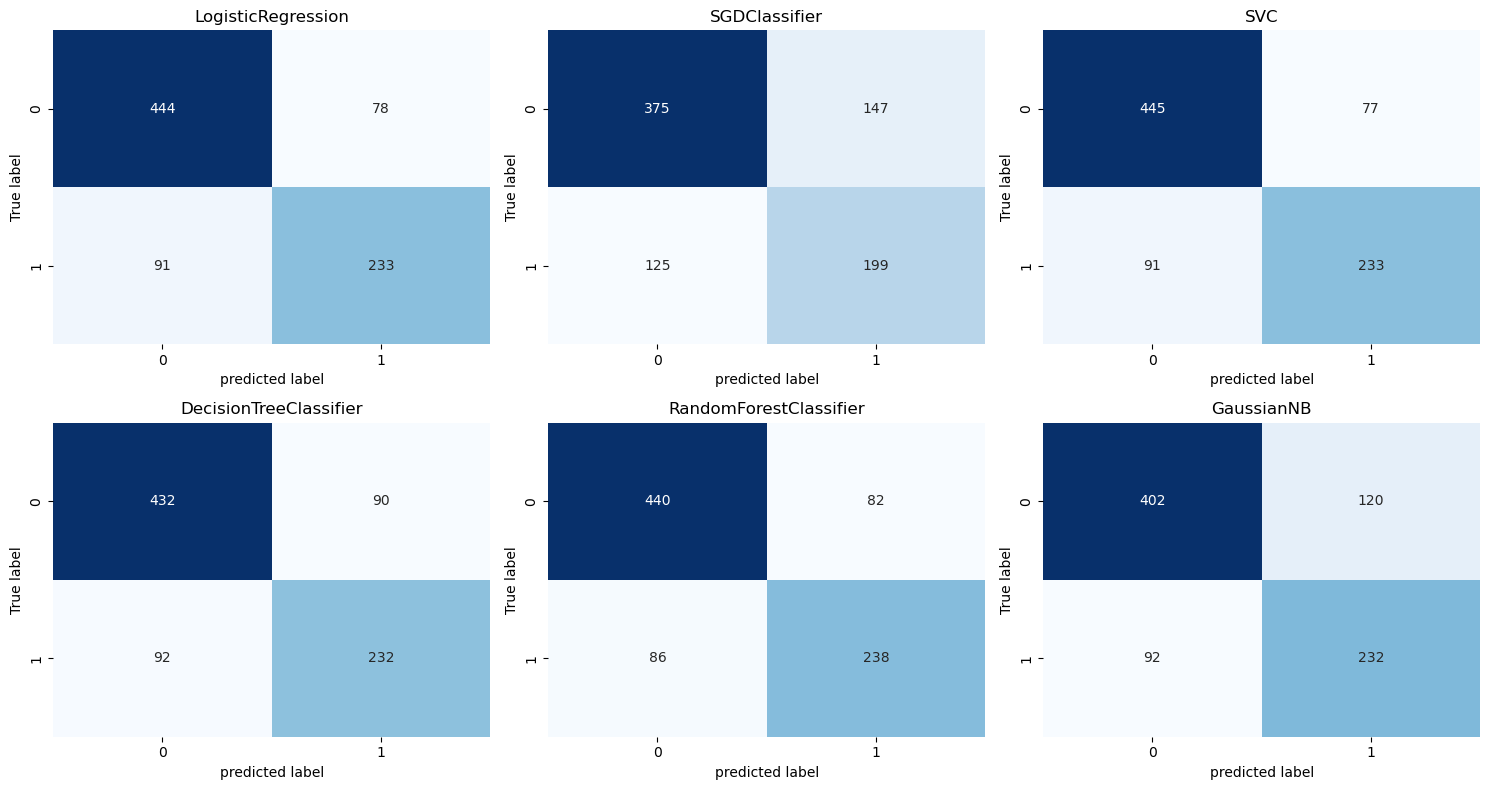

In [965]:
plt.figure(figsize=(15,8))
for i , clf in enumerate(classifiers, 1):
    class_name, conf_val = conf_matrix(clf, X_train, y_train)
    plt.subplot(2, 3, i)
    sns.heatmap(conf_val, annot=True, 
                fmt="d", cbar=False, 
                # xticklabels=clf.classes_, 
                # yticklabels=clf.classes_, 
                cmap="Blues")
    plt.title(class_name)
    plt.xlabel("predicted label")
    plt.ylabel("True label")

plt.tight_layout()
plt.show()

In [966]:
# %%writefile -a plot_utils.py

def roc_curve_plots(model_name, X_train, y_train):
    class_name = model_name["classifier"].__class__.__name__
    y_pred = cross_val_predict(model_name, X_train, y_train, cv=5)
    fpr, tpr, threshlds = roc_curve(y_train, y_pred)
    roc_auc = auc(fpr, tpr)
    return class_name, fpr, tpr, threshlds, roc_auc

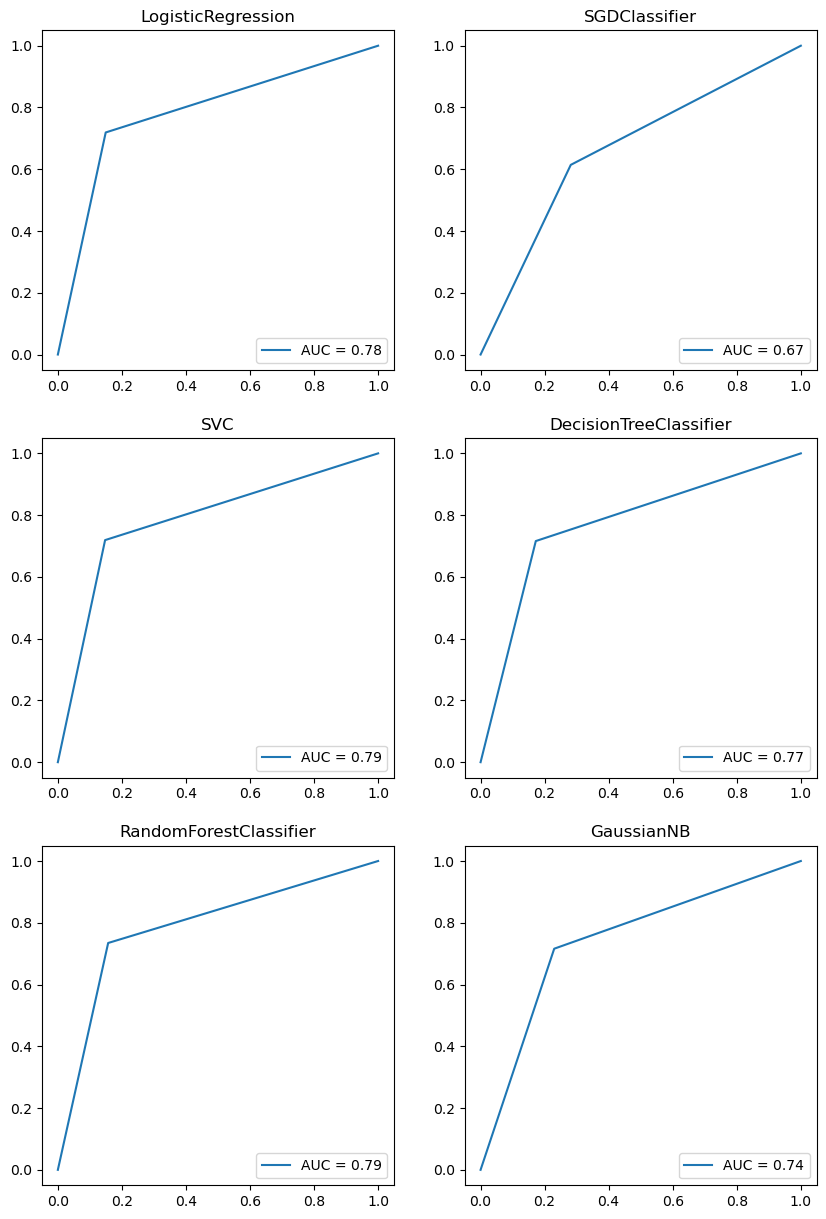

In [967]:
plt.figure(figsize=(10, 15))
for i, clf in enumerate(classifiers, 1):
    plt.subplot(3, 2, i)
    class_name, fpr, tpr, threshlds, roc_auc = roc_curve_plots(clf, X_train, y_train)
    plt.plot(fpr, tpr,  label = 'AUC = %0.2f' % roc_auc)
    plt.legend(loc = "lower right")
    plt.title(class_name)
plt.show()

In [968]:
# %%writefile -a model_utils.py

def model_predict(model_name, X_test, y_test):
    
    # filename = f"models/{model_name['classifier'].__class__.__name__}.joblib"
    # model = joblib.load(filename)
    start_time = time.time()
    y_pred = model_name.predict(X_test)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    end_time = time.time()

    class_name = model_name["classifier"].__class__.__name__
    metrics = {"precision": np.round(precision*100, 3),
               "recall": np.round(recall*100, 3),
               "f1 score": np.round(f1*100, 3),
               "Running time": np.round(end_time-start_time, 4)}
    
    return class_name, metrics

In [969]:
X_train.columns

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [970]:
# classifiers = [logistic_clf, sgd_clf, svc_clf, decision_tree_clf, random_forest_clf, naive_bayes_clf]

val_results = {}

for clf in classifiers:
    
    class_name, metrics = model_predict(clf, X_val, y_val)
    val_results[class_name] = metrics

In [971]:
pred_df = pd.DataFrame.from_dict(data=results, orient="index")
pred_df

,accuracy,roc,precision,recall,f1 score,Running time
LogisticRegression,81.087,85.896,76.623,72.840,74.684,0.1184
SGDClassifier,82.033,NaN,80.282,70.370,75.000,0.0390
SVC,80.142,NaN,75.161,71.914,73.502,0.0724
DecisionTreeClassifier,98.463,99.938,99.365,96.605,97.966,0.0463
RandomForestClassifier,98.463,99.752,99.054,96.914,97.972,0.1821
GaussianNB,75.296,82.442,66.476,71.605,68.945,0.0360


In [972]:
def predict_new_data(new_data:pd.DataFrame, model_path="models/RandomForestClassifier.joblib"):
    # model = load_model(model_name="RandomForestClassifier", model_path=model_path)
    model = joblib.load(model_path)
    predictions = model.predict(new_data)
    # probabilities = model.predict_proba(new_data)
    return predictions

In [973]:
X_test = pd.DataFrame([{'Pclass': 3.,'Name': 'Braund, Mr. Owen Harris', 'Sex': 'male',
                'Age': 22.0, 'SibSp': 1, 'Parch': 0, 'Ticket': 'A/5 21171', 'Fare': 7.2500,
                'Cabin':'NaN', 'Embarked':'S'}])

predict_new_data(new_data=X_test)[0]

0